In [19]:
"""
Plot three-phase voltage and current signals from an electrical fault dataset.
 
Reads: C:\\Users\\admin\\Downloads\\classData.csv
Produces a 2x2 grid of plots:
    1. Three Phase Voltage (Va, Vb, Vc)
    2. Ia
    3. Three Phase Voltage (Zoomed range)
    4. Ib
"""
 
import pandas as pd
import matplotlib.pyplot as plt

In [21]:

# ---------------------------------------------------------------------------
FILE_PATH = r"C:\Users\admin\Downloads\classData.csv"
 
try:
    df = pd.read_csv(FILE_PATH)
    print(f"Loaded '{FILE_PATH}' successfully. Shape: {df.shape}")
    print("Columns found:", df.columns.tolist())
except FileNotFoundError:
    raise SystemExit(f"ERROR: File not found at '{FILE_PATH}'. Please check the path.")
except Exception as e:
    raise SystemExit(f"ERROR: Could not read CSV file. Details: {e}")
 

Loaded 'C:\Users\admin\Downloads\classData.csv' successfully. Shape: (7861, 10)
Columns found: ['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']


In [22]:
if 'Time' in df.columns:
    x_axis = df['Time']
    x_label = 'Time'
    print("Using 'Time' column as x-axis.")
else:
    x_axis = df.index
    x_label = 'Sample Index'
    print("No 'Time' column found. Using row index as x-axis instead.")

No 'Time' column found. Using row index as x-axis instead.


In [23]:
def plot_three_phase_voltage(ax, x, data, title, x_range=None):
    """
    Plots Va, Vb, Vc on the given axis if the columns exist.
    If x_range (a slice) is provided, only that portion of data is plotted (zoom).
    If any/all voltage columns are missing, an informative message is shown instead.
    """
    voltage_cols = ['Va', 'Vb', 'Vc']
    available_cols = [col for col in voltage_cols if col in data.columns]
    missing_cols = [col for col in voltage_cols if col not in data.columns]
 
    if not available_cols:
        ax.text(0.5, 0.5, "Voltage columns (Va, Vb, Vc) not found in CSV",
                 ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
        ax.set_title(title)
        return
 
    if missing_cols:
        print(f"Warning: Missing voltage column(s) for '{title}': {missing_cols}")
 
    colors = {'Va': 'red', 'Vb': 'green', 'Vc': 'blue'}
 
    if x_range is not None:
        x_plot = x[x_range]
        for col in available_cols:
            ax.plot(x_plot, data[col].iloc[x_range], label=col, color=colors[col], linewidth=1)
    else:
        for col in available_cols:
            ax.plot(x, data[col], label=col, color=colors[col], linewidth=1)
 
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Voltage')
    ax.legend()
    ax.grid(True)
 
 
def plot_single_signal(ax, x, data, column_name, title, color):
    """
    Plots a single current signal (e.g., Ia or Ib) on the given axis if the column exists.
    Shows an informative message on the plot if the column is missing.
    """
    if column_name not in data.columns:
        ax.text(0.5, 0.5, f"Column '{column_name}' not found in CSV",
                 ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
        ax.set_title(title)
        return
 
    ax.plot(x, data[column_name], label=column_name, color=color, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Current')
    ax.legend()
    ax.grid(True)

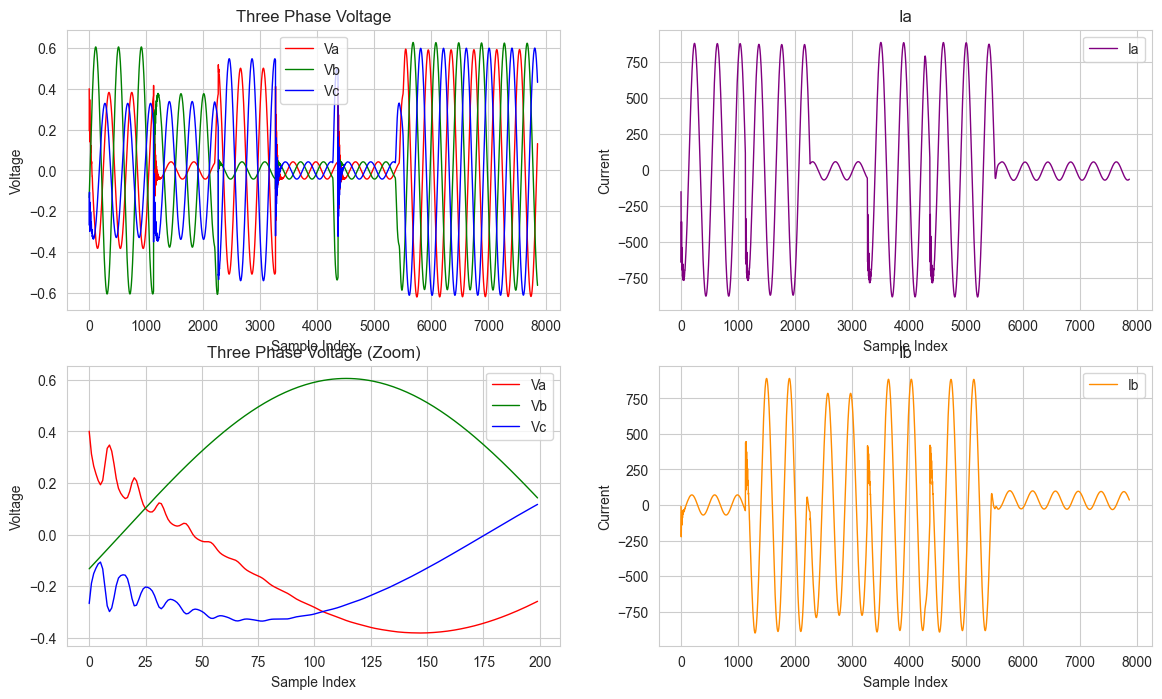

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
 
# Subplot 1: Three Phase Voltage (full range)
plot_three_phase_voltage(axes[0, 0], x_axis, df, 'Three Phase Voltage')
 
# Subplot 2: Ia
plot_single_signal(axes[0, 1], x_axis, df, 'Ia', 'Ia', color='purple')
 
# Subplot 3: Three Phase Voltage (Zoomed range - first 200 rows or fewer if data is smaller)
zoom_range = slice(0, min(200, len(df)))
plot_three_phase_voltage(axes[1, 0], x_axis, df, 'Three Phase Voltage (Zoom)', x_range=zoom_range)
 
# Subplot 4: Ib
plot_single_signal(axes[1, 1], x_axis, df, 'Ib', 'Ib', color='darkorange')

In [25]:
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>